In [1]:
import cogsworth
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import gala.dynamics as gd
import gala.potential as gp
from gala.units import galactic
from scipy.integrate import cumulative_trapezoid
from astropy.coordinates import SkyCoord

import sys
sys.path.append('../src')
import plotting, helpers
from importlib import reload

In [2]:
%config InlineBackend.figure_format = 'retina'


pd.options.display.max_columns = 999

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

In [ ]:
reload(helpers)
n_parts = 3

pops = [
    helpers.load_distributed_pop("/mnt/ceph/users/twagg/underworld/qcflag-5", n_parts, label="Disberg+2025", colour="C0"),
    helpers.load_distributed_pop("/mnt/ceph/users/twagg/underworld/kickflag-1", n_parts, label="Hobbs+2005", colour="C1"),
    helpers.load_distributed_pop("/mnt/ceph/users/twagg/underworld/bhflag-3", n_parts, label="Disberg+2025\n(no fallback scaling)", colour="C0"),
]

Loading distributed population Disberg+2025 from 3 parts
   loaded part 1/3 of Disberg+2025 with 179379 binaries
   loaded part 2/3 of Disberg+2025 with 178696 binaries
   loaded part 3/3 of Disberg+2025 with 177856 binaries
Loading distributed population Hobbs+2005 from 3 parts
   loaded part 1/3 of Hobbs+2005 with 179380 binaries
   loaded part 2/3 of Hobbs+2005 with 178696 binaries
   loaded part 3/3 of Hobbs+2005 with 177855 binaries
Loading distributed population Disberg+2025 (no fallback scaling) from 3 parts
   loaded part 1/3 of Disberg+2025 (no fallback scaling) with 179380 binaries
   loaded part 2/3 of Disberg+2025 (no fallback scaling) with 178696 binaries
   loaded part 3/3 of Disberg+2025 (no fallback scaling) with 177855 binaries


In [13]:
linestyles = ["-", "-", ":"]
for i, pop in enumerate(pops):
    pop.linestyle = linestyles[i]

In [14]:
kinematics = helpers.get_kinematics(pops)

In [15]:
print("Escaped fractions:")
for pop in pops:
    escaped = kinematics[pop.label]["escaped"]["CO"]
    frac = escaped.sum() / len(escaped)
    print(f'  - {pop.label}:')
    print(f'      - CO = {kinematics[pop.label]["escaped"]["CO"].sum() / len(kinematics[pop.label]["escaped"]["CO"]):1.3f}')
    print(f'      - BH = {kinematics[pop.label]["escaped"]["BH"].sum() / len(kinematics[pop.label]["escaped"]["BH"]):1.3f}')
    print(f'      - NS = {kinematics[pop.label]["escaped"]["NS"].sum() / len(kinematics[pop.label]["escaped"]["NS"]):1.3f}')

Escaped fractions:
  - Disberg+2025:
      - CO = 0.107
      - BH = 0.029
      - NS = 0.136
  - Hobbs+2005:
      - CO = 0.162
      - BH = 0.030
      - NS = 0.212
  - Disberg+2025 (no fallback scaling):
      - CO = 0.143
      - BH = 0.161
      - NS = 0.136


597590
599894
598748


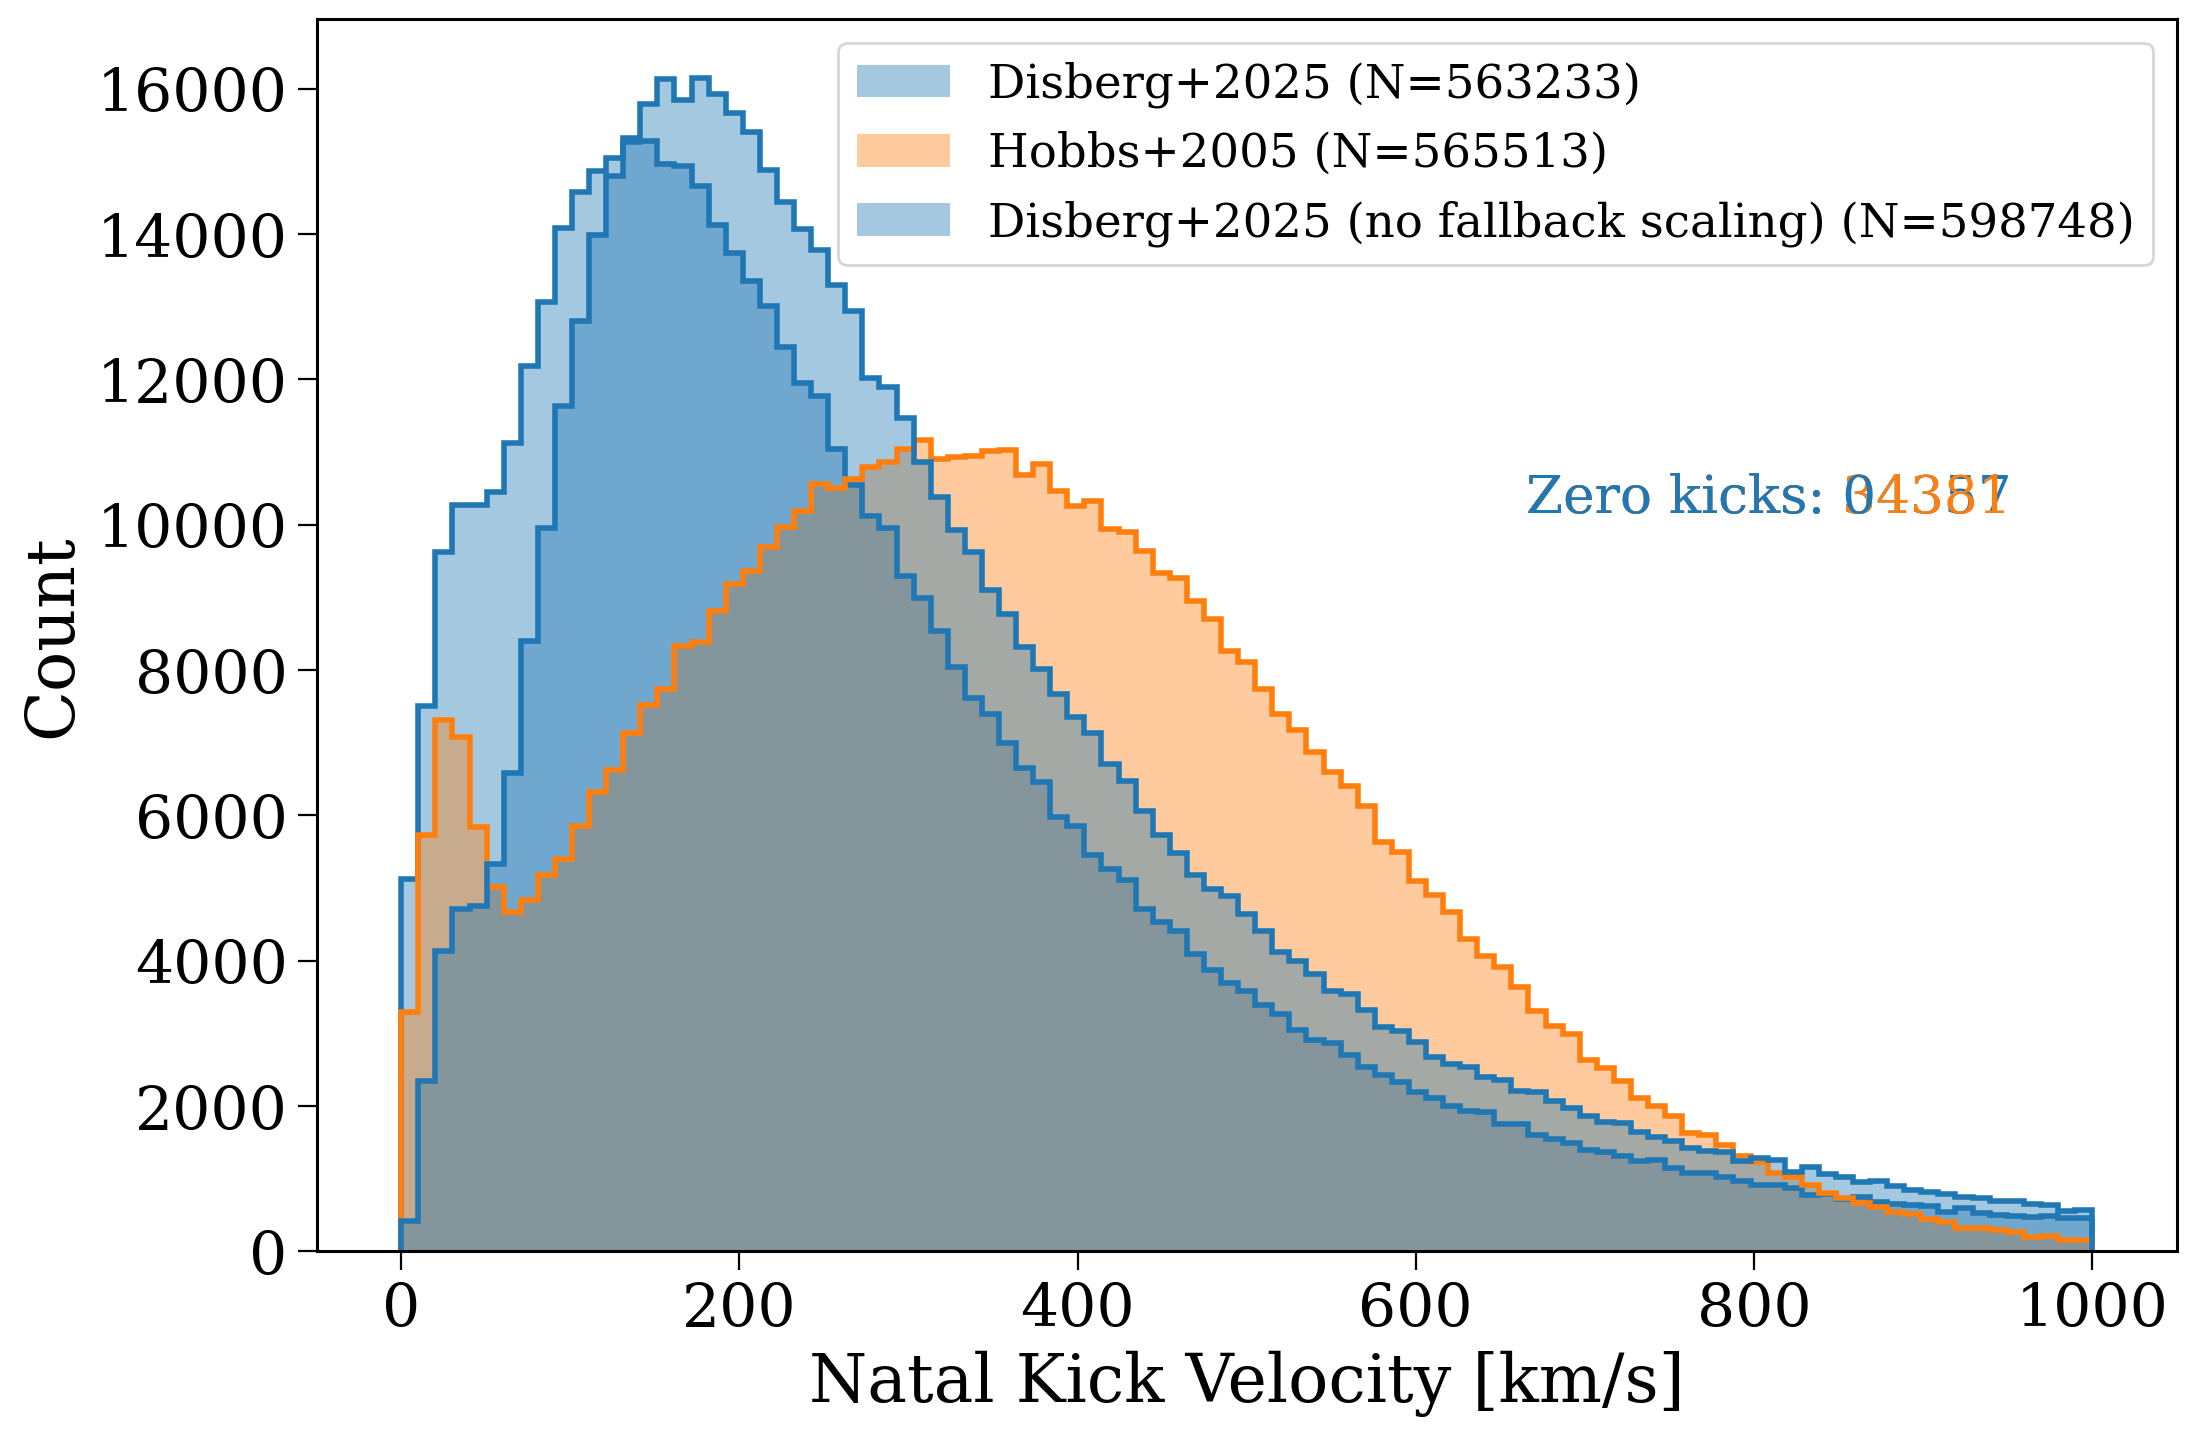

597590
599894
598748


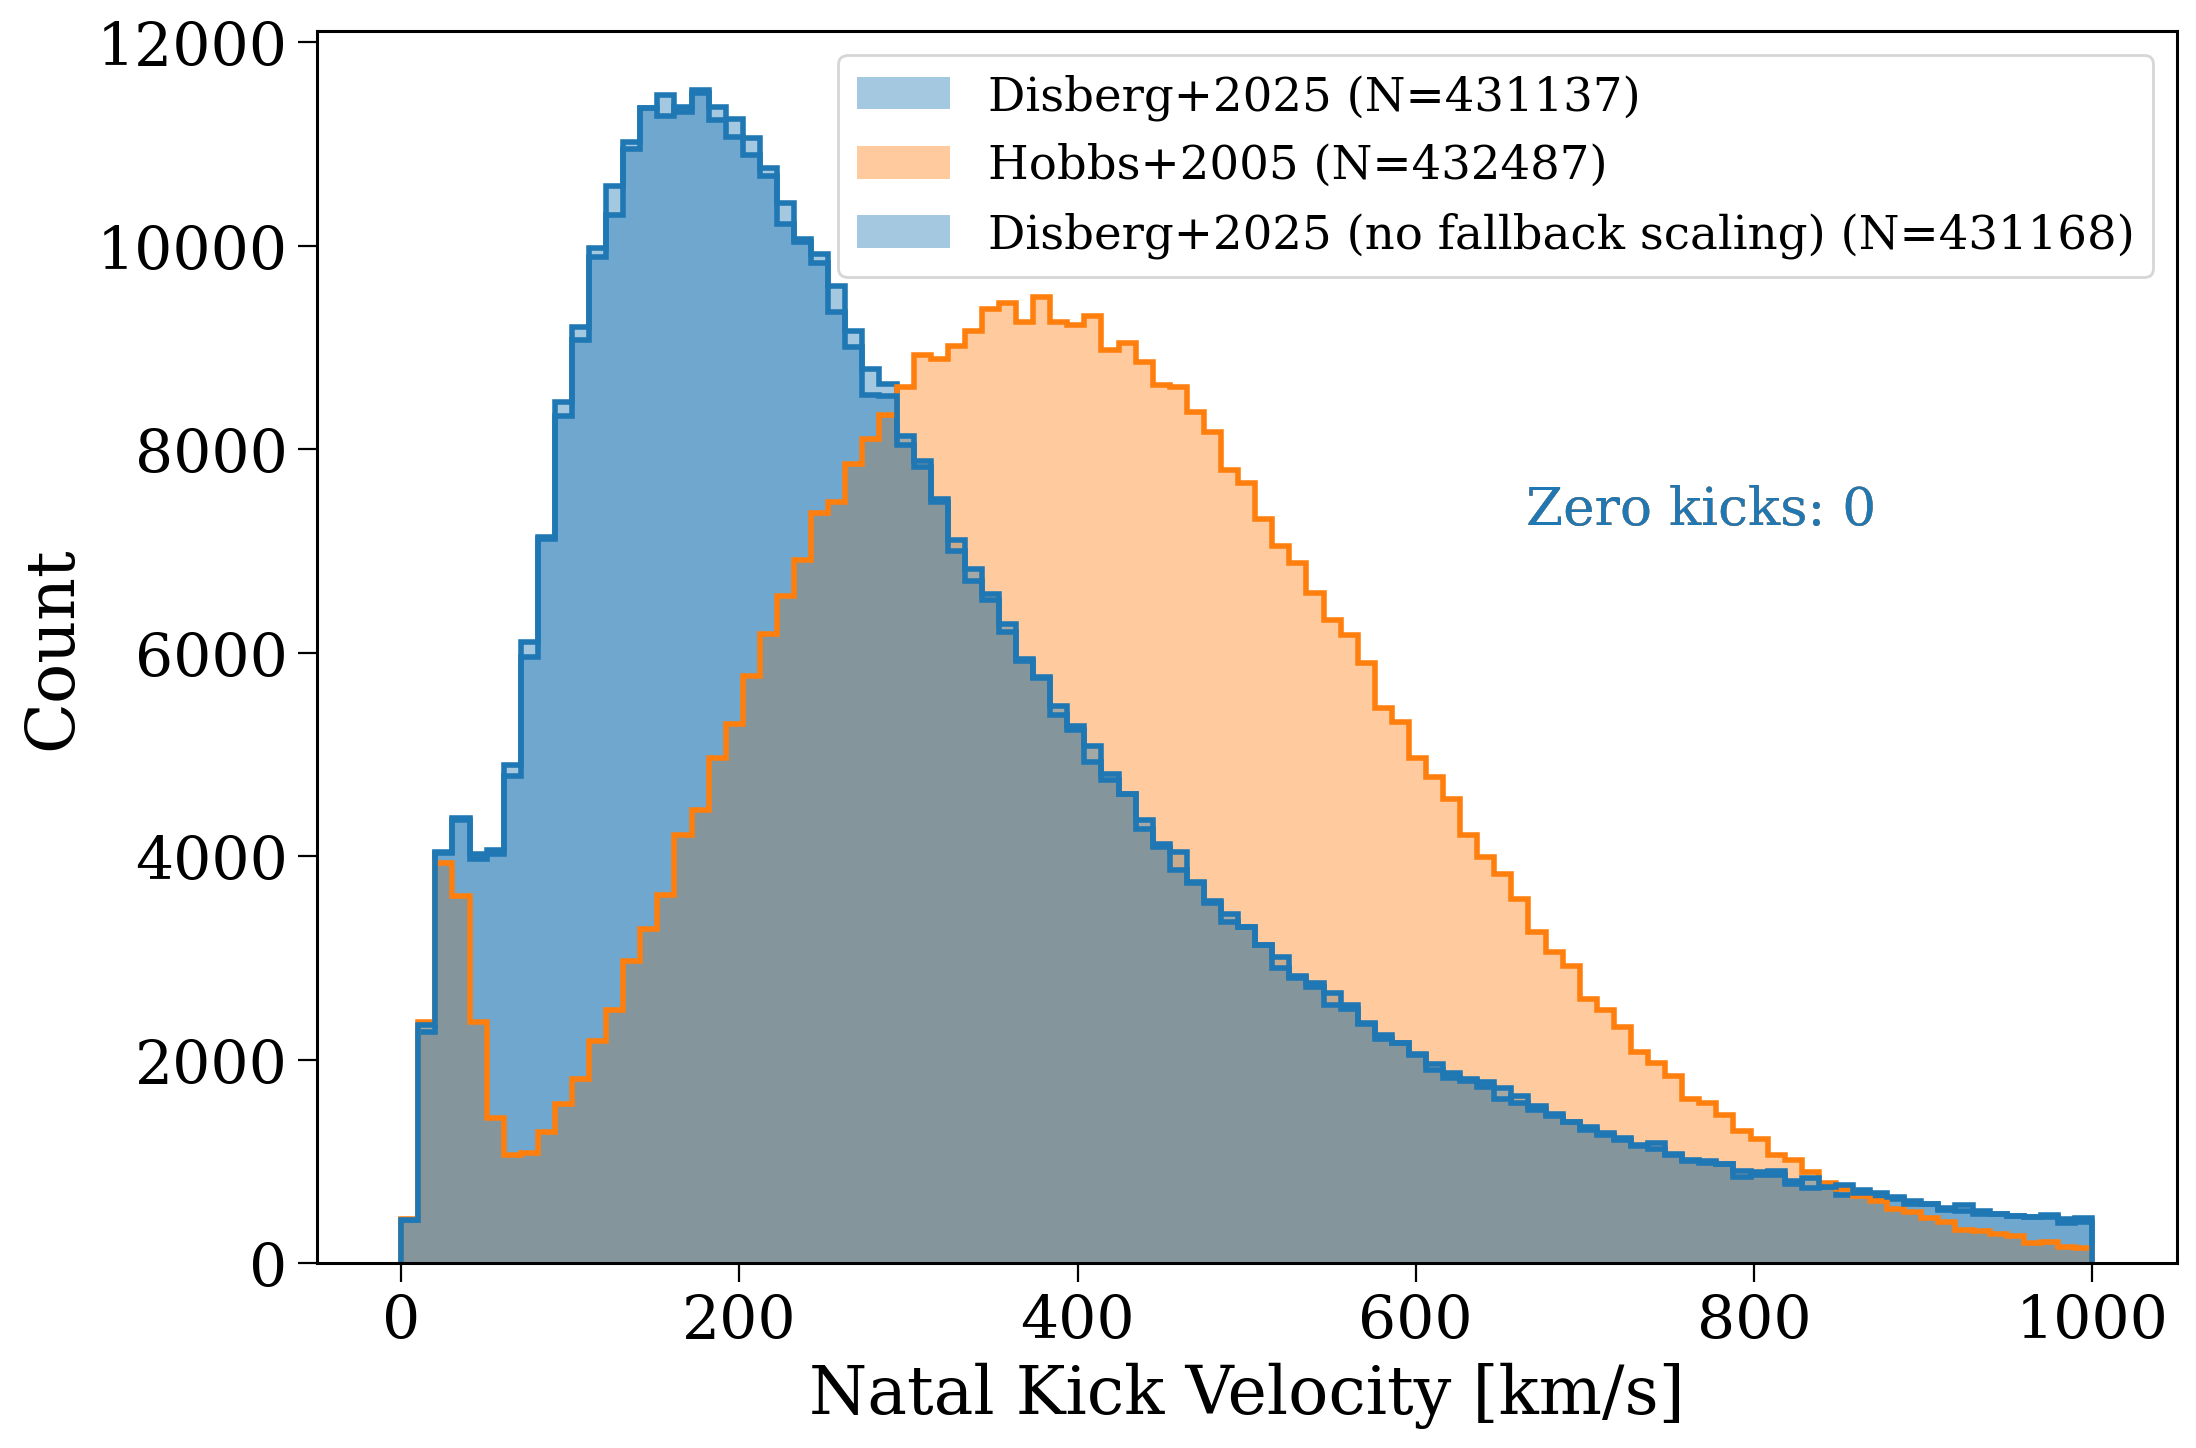

597590
599894
598748


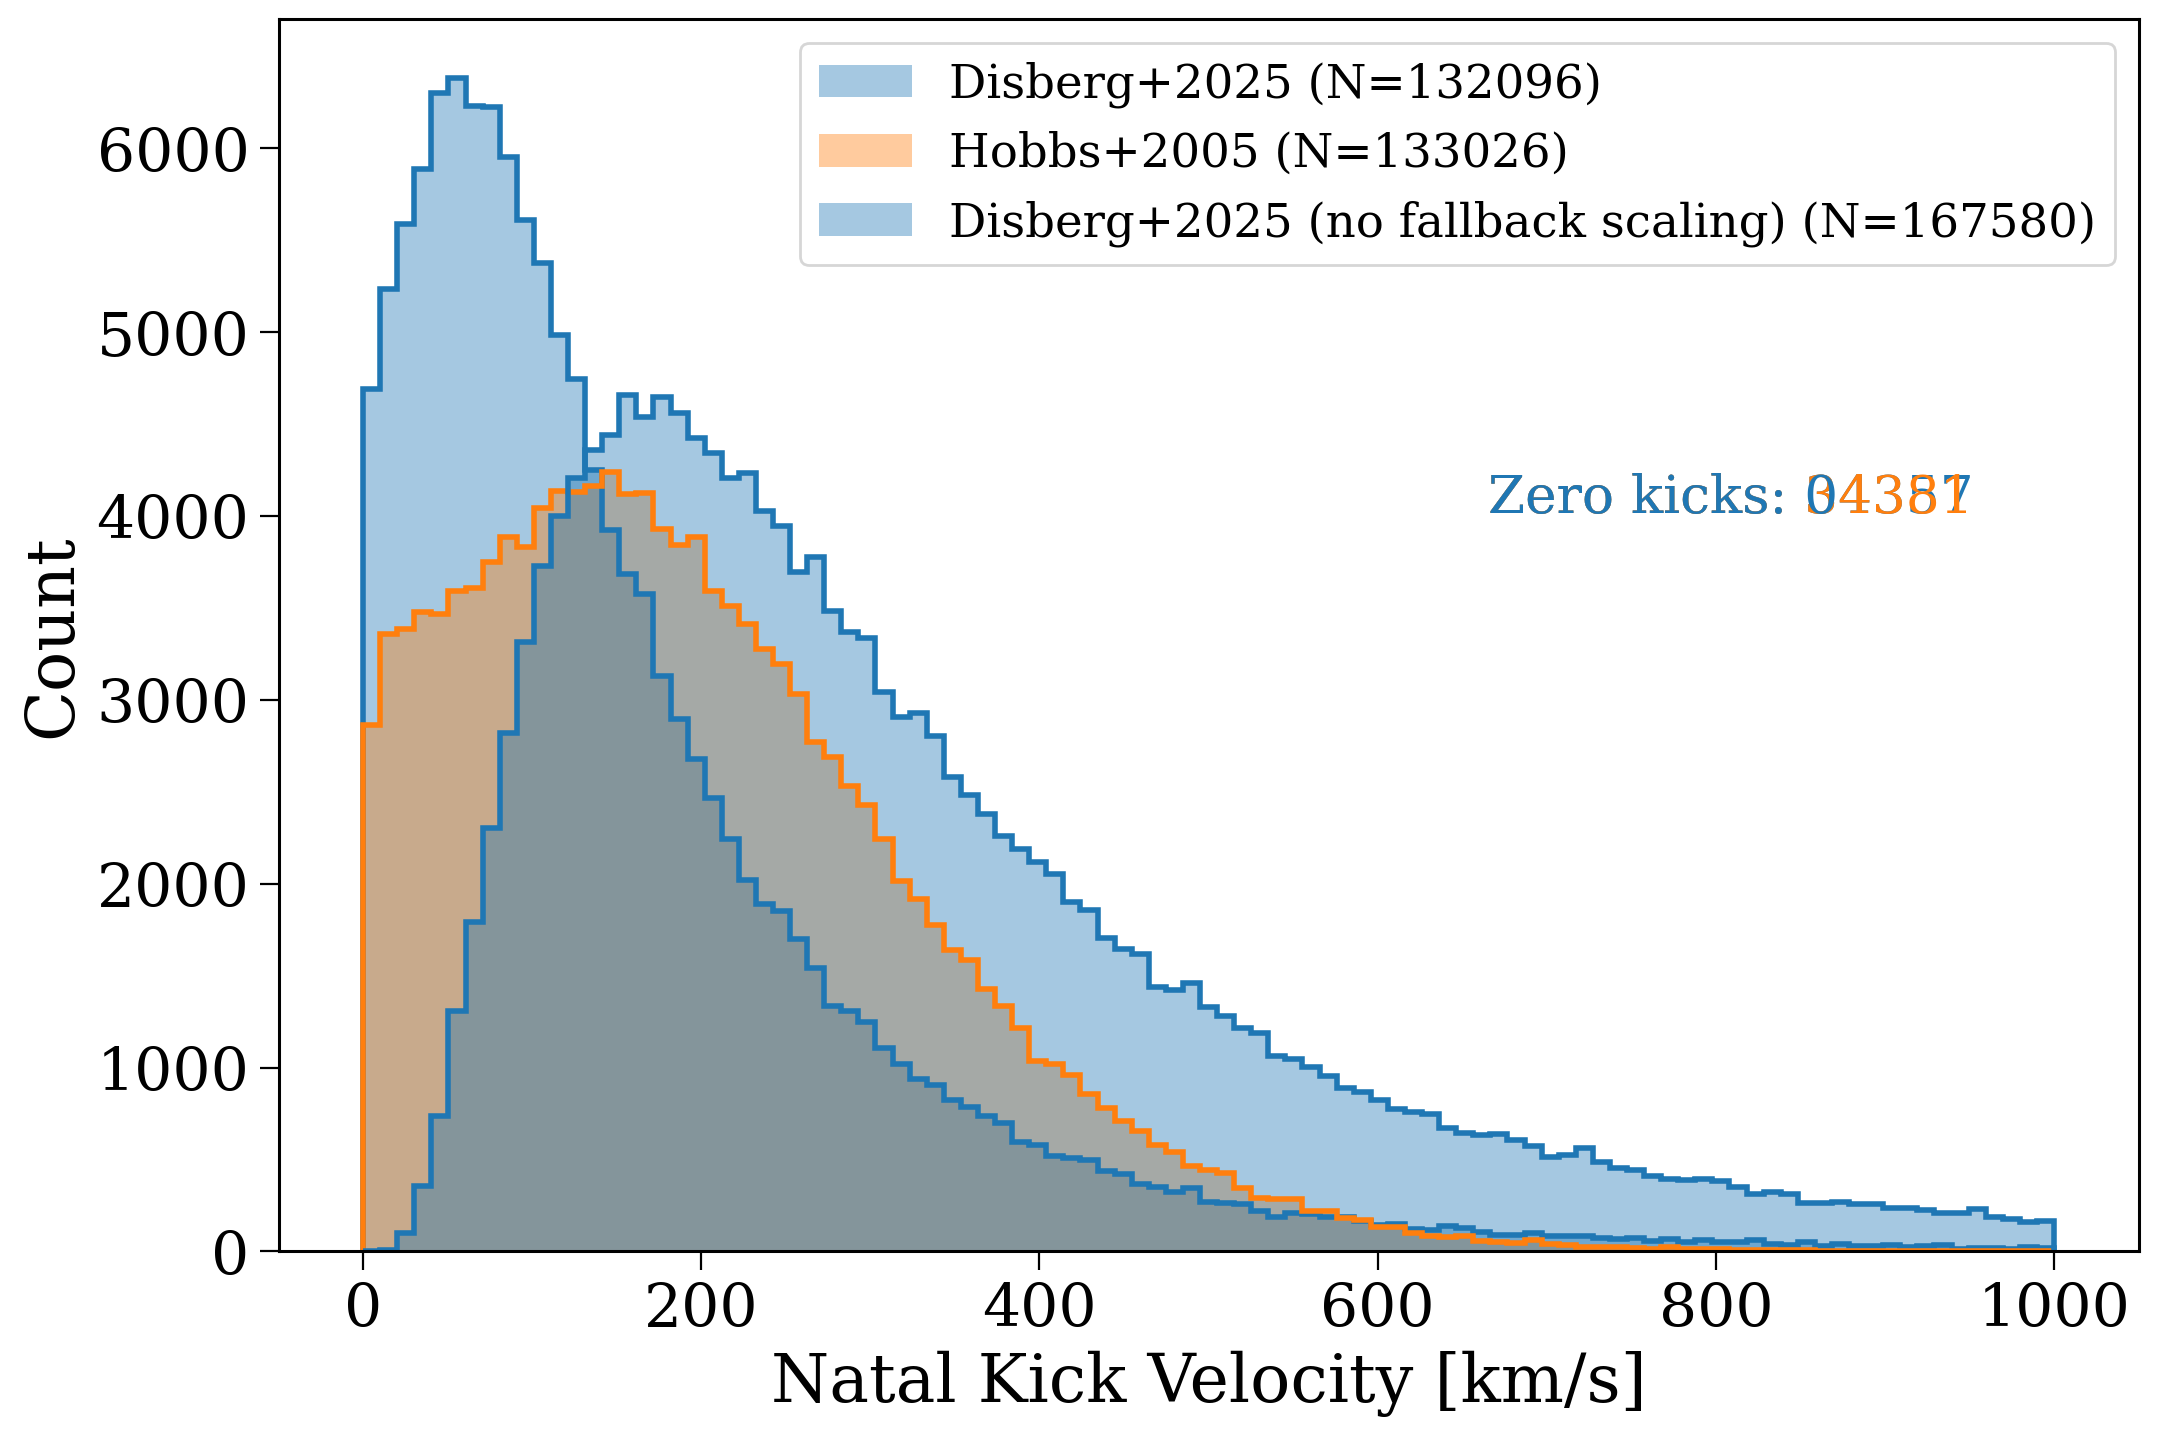

In [16]:
density = False
for co_type_label, co_type in zip(["ALL", "NS", "BH"], [[13, 14], [13], [14]]):

    fig, ax = plt.subplots()

    bins = np.linspace(0, 1000, 100)

    for pop in pops:
        kick_details = pop.kick_info[pop.kick_info["star"] != 0]
        kicks = kick_details["natal_kick"]
        print(len(kicks))

        kick_rows = pop.bpp[pop.bpp["evol_type"].isin([15, 16])]
        after_kick_rows = pop.bpp[pop.bpp["row_num"].isin(kick_rows["row_num"] + 1)]
        kick_co_type = np.where(kick_details["star"] == 1, after_kick_rows["kstar_1"], after_kick_rows["kstar_2"])
        
        kicks = kicks[(np.isin(kick_co_type, co_type))]
        n_zero_kicks = (kicks == 0.0).sum()
        kicks = kicks[(kicks != 0.0)]

        ax.hist(kicks, bins=bins, density=density, histtype='step', lw=2, color=pop.colour)
        ax.hist(kicks, bins=bins, density=density, alpha=0.4, color=pop.colour,
                label=f"{pop.label} (N={len(kicks)})")
        
        ax.annotate(
            f"Zero kicks: {n_zero_kicks}",
            xy=(0.65, 0.65 - 0.05 * (0 if pop.label == "Singles" else 1)),
            xycoords='axes fraction',
            color=pop.colour,
            fontsize=0.8*fs,
        )

    ax.set(
        xlabel="Natal Kick Velocity [km/s]",
        ylabel="Count",
    )
    ax.legend()
    plt.show()

[ 3.30717527 11.72474025 22.29365528 25.14456598]
[ 3.19386014 10.1885942  19.37188867 24.78335131]
[ 4.75618965 10.91367554 16.34887292 41.52463958]


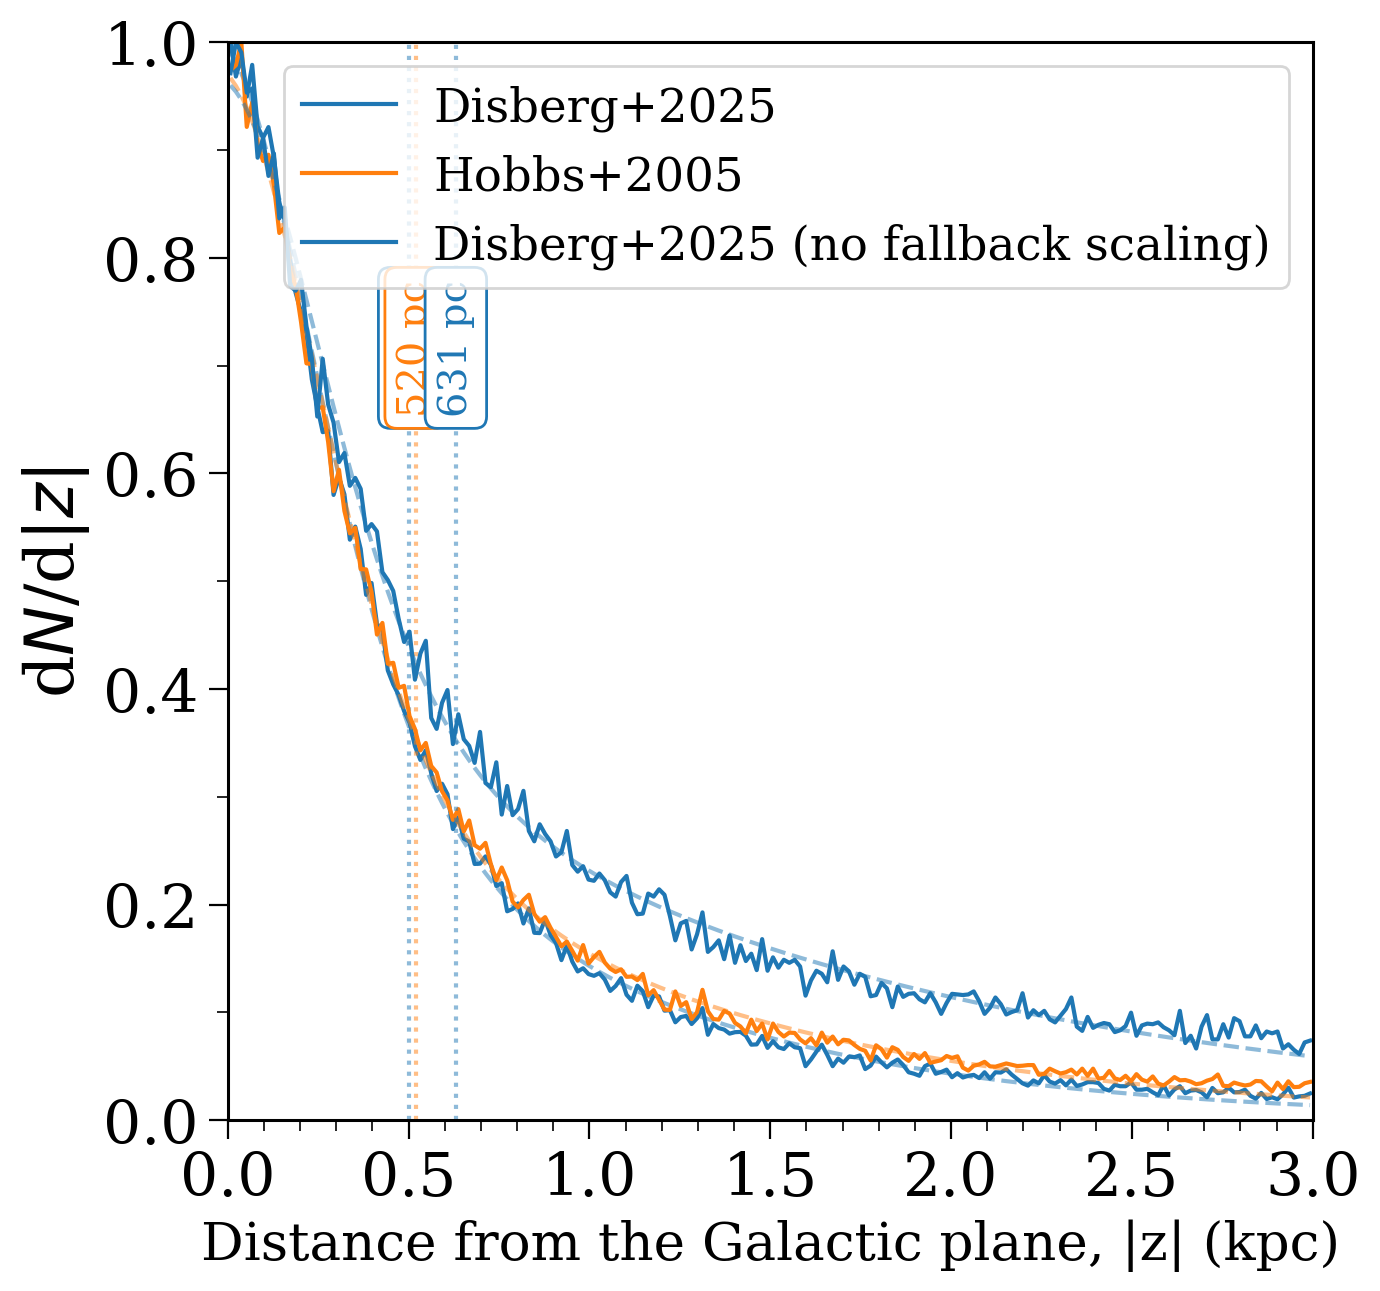

In [17]:
fig, ax = plt.subplots(figsize=(7, 7))

reload(plotting)

for pop in pops:

    scale_height, _, _ = plotting.estimate_scale_height(
        z=kinematics[pop.label]["pos"]["BH"][:, 2],
        plot=True,
        label=pop.label,
        colour=pop.colour,
        show=False,
        fig=fig,
        ax=ax,
        bins=np.linspace(0, 3, 201),
        xlim=(0, 3),
        ylim=(0, 1),
        n_components=2,
        scale_height_locs=[0.78, 0.22],
        R=None,
    )

# add minor ticks every 0.1 kpc
ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))

# plt.savefig("../plots/scale_height_blackholes_vs_stars.pdf", format="pdf", bbox_inches='tight')
plt.show()

In [24]:
masses = {}

for pop in pops:
    mass = {
        "BH": np.concatenate((
            pop.final_bpp["mass_1"][pop.final_bpp["kstar_1"] == 14],
            pop.final_bpp["mass_2"][pop.final_bpp["kstar_2"] == 14],
        )),
        "NS": np.concatenate((
            pop.final_bpp["mass_1"][pop.final_bpp["kstar_1"] == 13],
            pop.final_bpp["mass_2"][pop.final_bpp["kstar_2"] == 13],
        )),
    }
    mass["CO"] = np.concatenate((mass["NS"], mass["BH"]))
    masses[pop.label] = mass

In [19]:
print("Average BH masses:")
print("------------------")

for pop in pops:
    masses = mass[pop.label]

    average_escaped_BH_mass = np.mean(masses["BH"][kinematics[pop.label]["escaped"]["BH"]])
    average_bound_BH_mass = np.mean(masses["BH"][~kinematics[pop.label]["escaped"]["BH"]])

    avg_bound_BH_close_to_disc = np.mean(masses["BH"][(
        ~kinematics[pop.label]["escaped"]["BH"] &
        (abs(kinematics[pop.label]["pos"]["BH"][:, 2].to(u.kpc).value) < 1)
    )])

    avg_bound_BH_far_from_disc = np.mean(masses["BH"][(
        ~kinematics[pop.label]["escaped"]["BH"] &
        (abs(kinematics[pop.label]["pos"]["BH"][:, 2].to(u.kpc).value) >= 1)
    )])

    print(f"{pop.label}")
    print(f"  Escaped: {average_escaped_BH_mass:.1f} Msun")
    print(f"  Bound:   {average_bound_BH_mass:.1f} Msun")
    print(f"    Close to disc (<1 kpc):  {avg_bound_BH_close_to_disc:.1f} Msun")
    print(f"    Far from disc (>=1 kpc): {avg_bound_BH_far_from_disc:.1f} Msun")
    print()

Average BH masses:
------------------
Disberg+2025
  Escaped: 5.2 Msun
  Bound:   10.7 Msun
    Close to disc (<1 kpc):  11.9 Msun
    Far from disc (>=1 kpc): 8.0 Msun

Hobbs+2005
  Escaped: 4.7 Msun
  Bound:   10.7 Msun
    Close to disc (<1 kpc):  12.5 Msun
    Far from disc (>=1 kpc): 7.7 Msun

Disberg+2025 (no fallback scaling)
  Escaped: 11.0 Msun
  Bound:   10.5 Msun
    Close to disc (<1 kpc):  9.7 Msun
    Far from disc (>=1 kpc): 11.0 Msun



In [25]:
z_range = np.geomspace(0.1, 10, 1000)

init_bh_z = np.concatenate((
    pops[0].initial_galaxy.z[pops[0].final_bpp["kstar_1"] == 14],
    pops[0].initial_galaxy.z[pops[0].final_bpp["kstar_2"] == 14]
))
init_abs_z = np.abs(init_bh_z.to(u.kpc).value)

mean_masses = helpers.get_average_mass_at_z(
    abs_zs=[np.abs(kinematics[pop.label]["pos"]["BH"][:, 2].to(u.kpc).value)
            for pop in pops] + [init_abs_z],
    bh_masses=[masses[pop.label]["BH"] for pop in pops] + [masses[pops[0].label]["BH"]],
    z_range=z_range,
    window_width=0.1
)

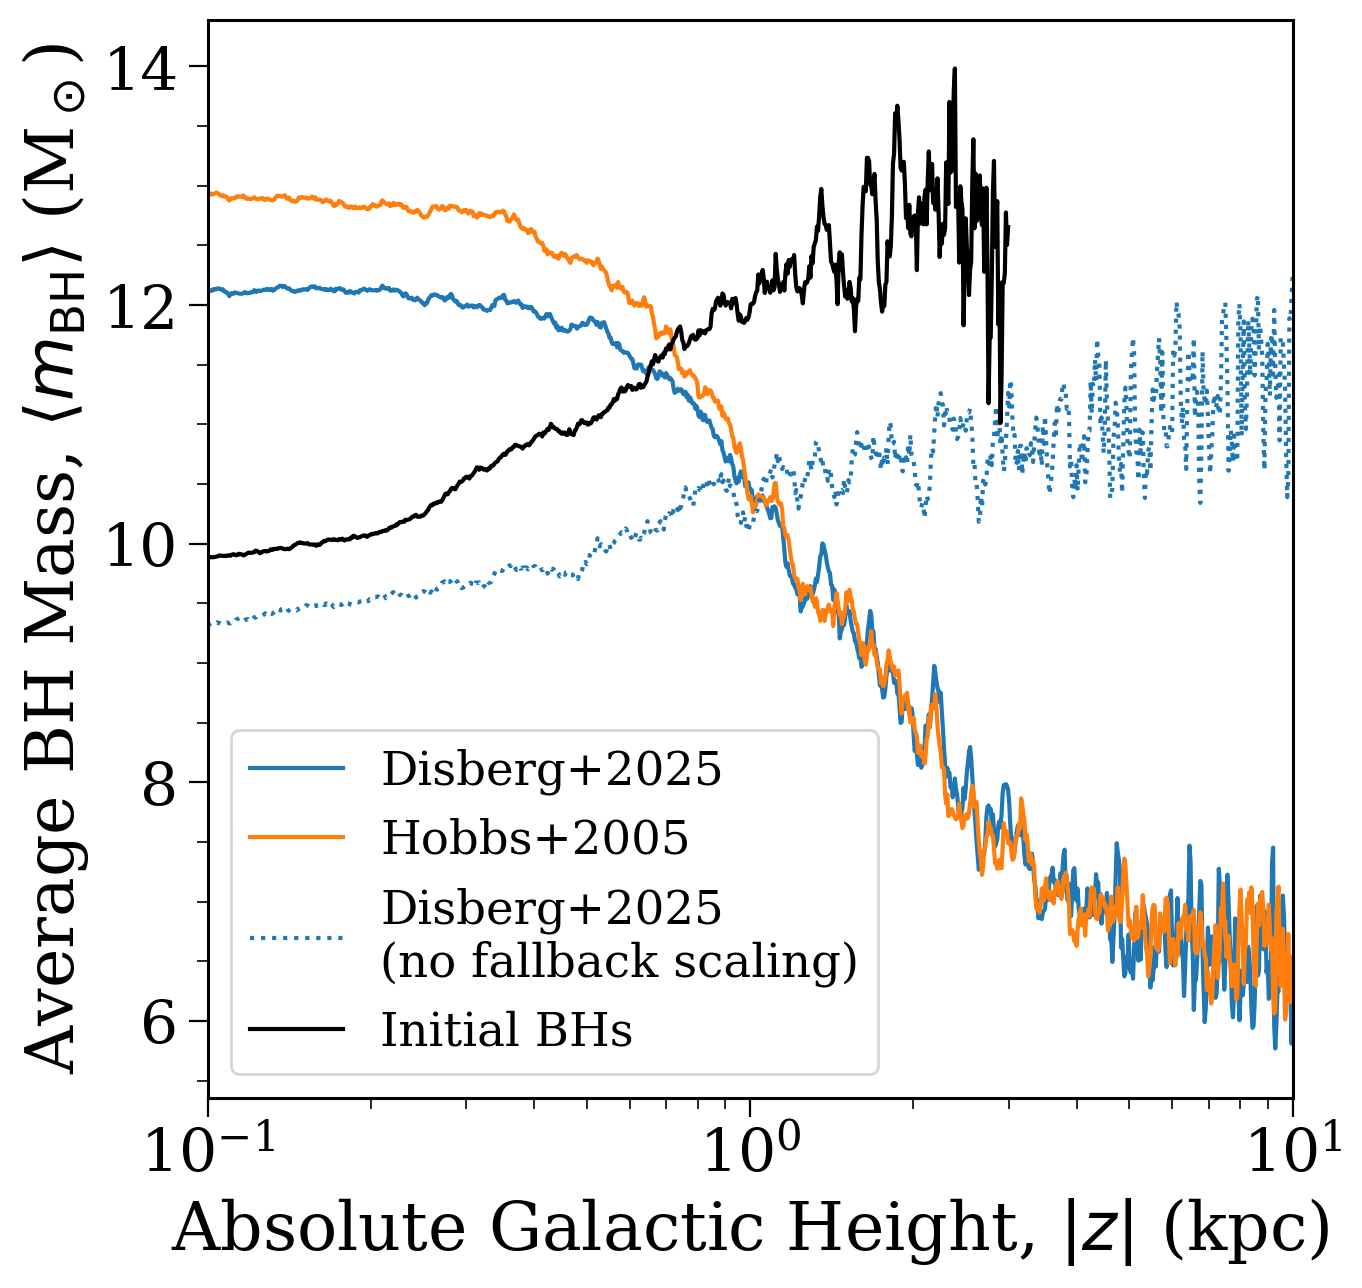

In [32]:
fig, ax = plt.subplots(figsize=(7, 7))

for i, pop in enumerate(pops):
    ax.plot(z_range, mean_masses[i], label=pop.label, color=pop.colour, linestyle=pop.linestyle)
ax.plot(z_range[z_range < 3], mean_masses[-1][z_range < 3],
        label="Initial BHs", color="black")

ax.set(
    xscale='log',
    xlabel=r'Absolute Galactic Height, $|z|$ (kpc)',
    ylabel=r'Average BH Mass, $\langle m_{\rm BH} \rangle$ (M$_\odot$)',
    xlim=(0.1, 10),
)

ax.legend()

ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.5))

plt.show()